Вы работаете аналитиком в компании, управляющей парком автомобилей каршеринга в большом городе. Компания хочет проанализировать данные за 6 месяцев, чтобы понять, как использовать автомобили эффективнее.

У вас есть файл carsharing.csv с колонками:

* Date — дата поездки (в формате YYYY-MM-DD)

* Car_ID — идентификатор автомобиля

* Duration_min — длительность аренды в минутах

* Distance_km — пройденное расстояние (км)

* Revenue — доход от поездки (руб.)

* Fuel_cost — стоимость топлива (руб.)

## Задания

#### 1. Предварительный анализ

Найдите 5 автомобилей с наибольшей выручкой за весь период.

Найдите 5 автомобилей с наименьшей средней рентабельностью (прибыль = Revenue - Fuel_cost).

#### 2. Временные ряды

Постройте график динамики средней выручки по дням.

Добавьте 7-дневное скользящее среднее.

#### 3. Будни vs выходные

Сравните среднюю длительность поездок, среднюю выручку и среднюю скорость (Distance_km / (Duration_min/60)) в будние и выходные дни.

Постройте сравнительные графики.

#### 4. Сравнительный анализ поездок

Постройте гистограмму длительности поездок и выделите аномально длинные поездки (выше 95-го перцентиля).

Постройте распределение средних скоростей.

#### 5. Кластеризация автомобилей

Для каждого автомобиля вычислите:

Среднюю выручку на поездку,

Среднюю длительность,

Среднюю скорость.

Проведите кластеризацию (3 кластера) с помощью k-means.

Постройте график кластеров и интерпретируйте их.

#### 6. Корреляции

Постройте корреляционную матрицу между признаками (Duration_min, Distance_km, Revenue, Fuel_cost, Avg_speed).

Визуализируйте её в виде тепловой карты.

#### 7. Прогнозирование

Используя полиномиальную регрессию (numpy.polyfit), постройте прогноз средней выручки на следующие 14 дней.

Нанесите прогноз на график вместе с реальными данными.

## Подсказки к заданиям

#### 1. Предварительный анализ

Используйте groupby в pandas для агрегирования по Car_ID.

Методы: .sum(), .mean(), .nlargest(), .nsmallest().

Введите новую колонку Profit = Revenue - Fuel_cost.

#### 2. Временные ряды

Сгруппируйте данные по Date, возьмите среднее (.groupby("Date").mean()).

Для скользящего среднего используйте .rolling(window=7).mean().

Визуализация: matplotlib.pyplot.plot().

#### 3. Будни vs выходные

Получите день недели через data["Date"].dt.weekday.

Будни: 0–4, выходные: 5–6.

Сравнение: снова groupby("IsWeekend").mean().

Визуализация: plot(kind="bar") или matplotlib.bar.

#### 4. Сравнительный анализ поездок

Постройте гистограмму с помощью plt.hist().

Найдите 95-й перцентиль через numpy.percentile().

Средняя скорость: создайте колонку Distance_km / (Duration_min/60).

Визуализация: гистограммы (plt.hist).

#### 5. Кластеризация автомобилей

Сначала агрегируйте данные по Car_ID (средние показатели).

Нормализация данных: StandardScaler из sklearn.preprocessing.

Кластеризация: KMeans(n_clusters=3) из sklearn.cluster.

Визуализация: plt.scatter() с цветами по меткам кластеров.

#### 6. Корреляции

Метод .corr() для расчёта матрицы корреляций.

Визуализация:

plt.imshow() (базовый способ),

или seaborn.heatmap() (более красиво, если библиотека разрешена).

#### 7. Прогнозирование

Создайте индекс-дни с помощью np.arange(len(daily_revenue)).

Аппроксимация: numpy.polyfit(x, y, deg=3) и numpy.poly1d().

Создайте прогноз на будущие точки (например, +14 дней).

Визуализация: plt.plot() для фактических данных и прогноза.

Топ-5 автомобилей по выручке:
 Car_ID
6     264686.269355
3     261458.505071
4     256774.532948
19    248381.019491
11    244779.253385
Name: Revenue, dtype: float64

5 автомобилей с наименьшей рентабельностью:
 Car_ID
9     2127.776355
10    2250.726717
7     2301.626746
8     2305.639149
5     2307.432708
Name: Profit, dtype: float64


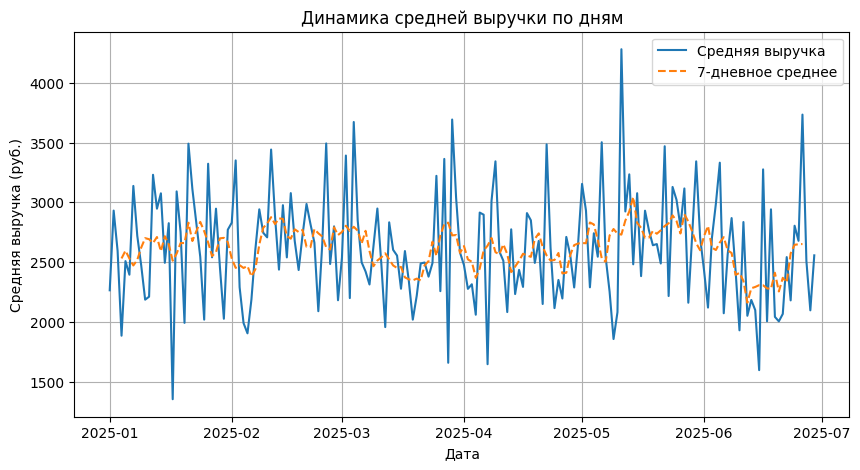


Будни vs выходные:
           Duration_min      Revenue  Avg_speed
Будни        97.073817  2598.999646  29.820577
Выходные     98.148454  2664.790735  30.063229


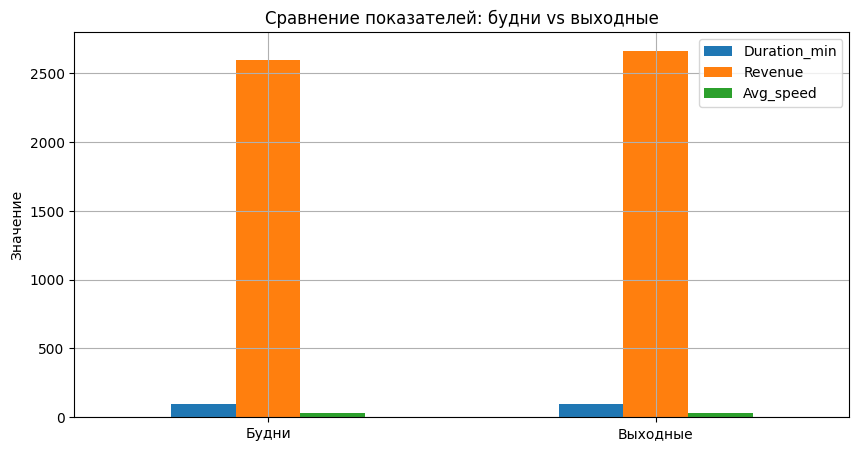

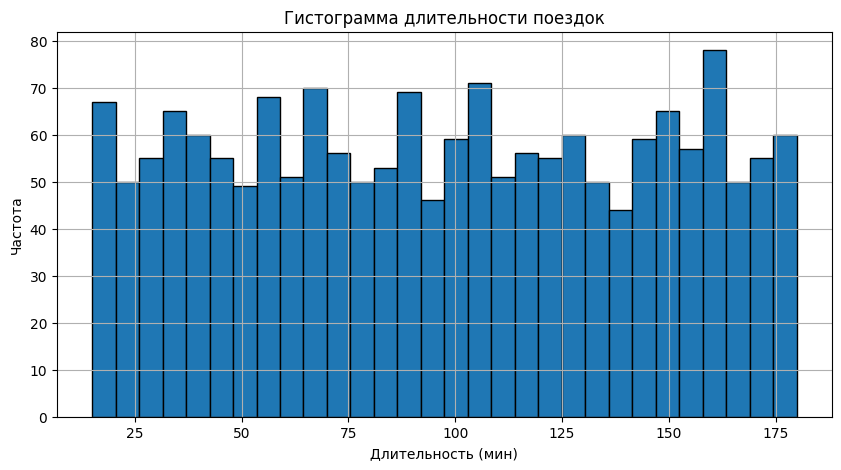

Аномальные поездки (выше 95-го перцентиля): 87


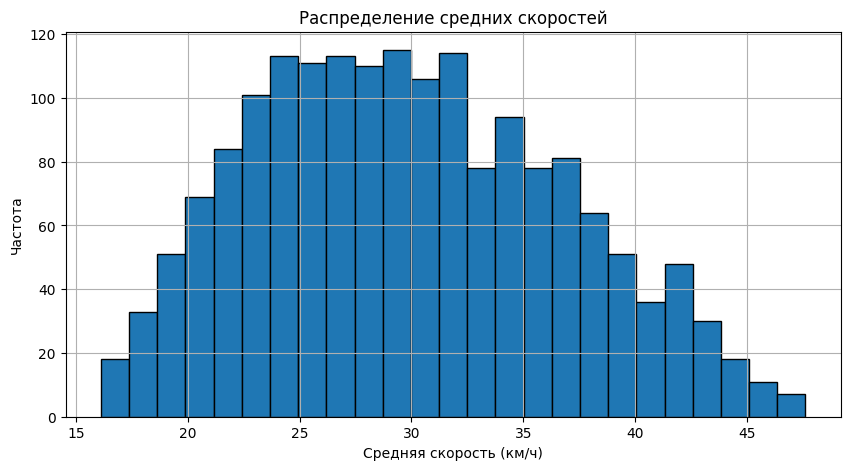

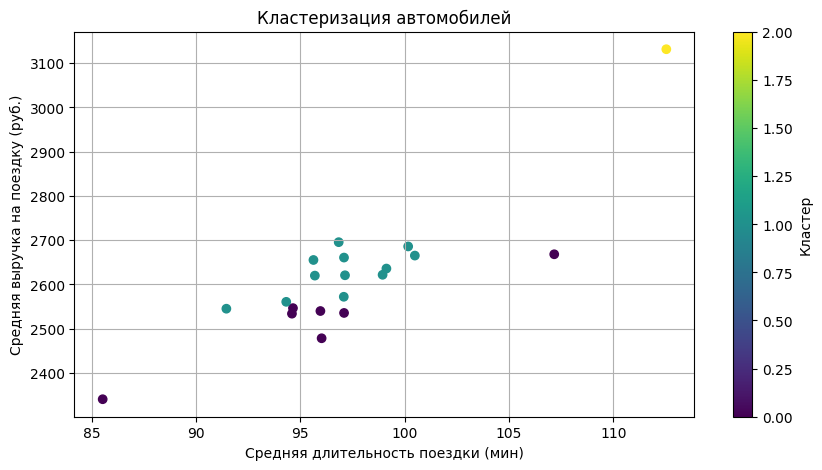


Характеристики кластеров:

Кластер 0:
Avg_Revenue     2520.380701
Avg_Duration      95.858863
Avg_Speed         29.141377
Cluster            0.000000
dtype: float64

Кластер 1:
Avg_Revenue     2628.175320
Avg_Duration      96.997593
Avg_Speed         30.218139
Cluster            1.000000
dtype: float64

Кластер 2:
Avg_Revenue     3131.396743
Avg_Duration     112.536605
Avg_Speed         30.804869
Cluster            2.000000
dtype: float64


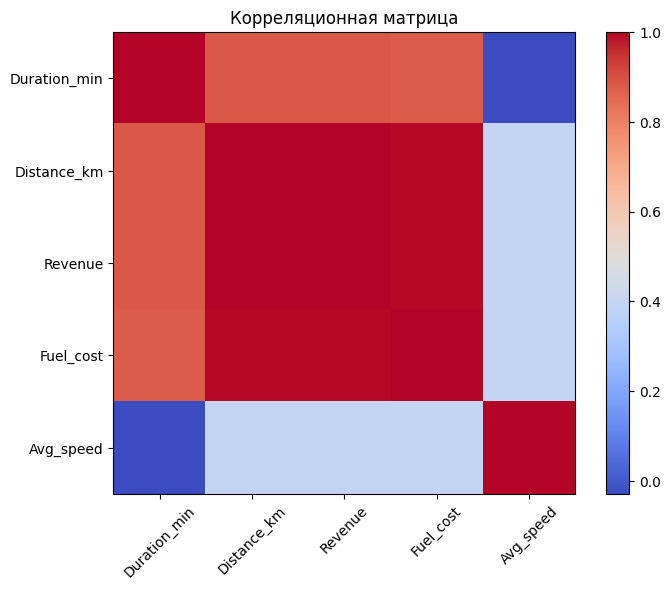

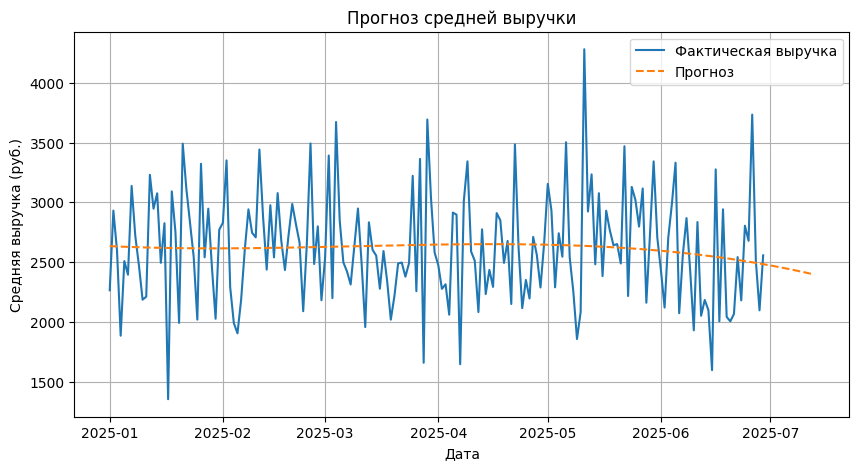

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# === 0. Загрузка данных ===
data = pd.read_csv("carsharing.csv", parse_dates=["Date"])

# Добавьте новые колонки
data["Profit"] = data["Revenue"] - data["Fuel_cost"]
data["Avg_speed"] = data["Distance_km"] / (data["Duration_min"] / 60)

# === 1. Предварительный анализ ===
# Топ-5 автомобилей по выручке
top_cars = data.groupby("Car_ID")["Revenue"].sum().nlargest(5)

# 5 автомобилей с наименьшей средней рентабельностью
low_profit_cars = data.groupby("Car_ID")["Profit"].mean().nsmallest(5)

print("Топ-5 автомобилей по выручке:\n", top_cars)
print("\n5 автомобилей с наименьшей рентабельностью:\n", low_profit_cars)

# === 2. Временные ряды ===
# Средняя выручка по дням
daily_revenue = data.groupby("Date")["Revenue"].mean()

# 7-дневное скользящее среднее
rolling_avg = daily_revenue.rolling(window=7, center=True).mean()

# Постройте график динамики
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue.index, daily_revenue.values, label="Средняя выручка")
plt.plot(daily_revenue.index, rolling_avg, label="7-дневное среднее", linestyle="--")
plt.title("Динамика средней выручки по дням")
plt.xlabel("Дата")
plt.ylabel("Средняя выручка (руб.)")
plt.legend()
plt.grid(True)
plt.show()

# === 3. Будни vs выходные ===
# Создайте колонку IsWeekend (True/False)
data["Weekday"] = data["Date"].dt.weekday
data["IsWeekend"] = data["Weekday"].isin([5, 6])

# Сравните средние значения
weekend_stats = data.groupby("IsWeekend")[["Duration_min", "Revenue", "Avg_speed"]].mean()
weekend_stats.index = ["Будни", "Выходные"]

print("\nБудни vs выходные:\n", weekend_stats)

# Постройте график
weekend_stats.plot(kind="bar", figsize=(10, 5))
plt.title("Сравнение показателей: будни vs выходные")
plt.ylabel("Значение")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

# === 4. Сравнительный анализ поездок ===
# Гистограмма длительности поездок
plt.figure(figsize=(10, 5))
plt.hist(data["Duration_min"], bins=30, edgecolor="black")
plt.title("Гистограмма длительности поездок")
plt.xlabel("Длительность (мин)")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

# Найдите 95-й перцентиль и выделите аномальные поездки
threshold = np.percentile(data["Duration_min"], 95)
anomalous_trips = data[data["Duration_min"] > threshold].shape[0]
print("Аномальные поездки (выше 95-го перцентиля):", anomalous_trips)

# Распределение средних скоростей
plt.figure(figsize=(10, 5))
plt.hist(data["Avg_speed"], bins=25, edgecolor="black")
plt.title("Распределение средних скоростей")
plt.xlabel("Средняя скорость (км/ч)")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

# === 5. Кластеризация автомобилей ===
# Рассчитайте средние показатели для каждого Car_ID
car_features = data.groupby("Car_ID")[["Revenue", "Duration_min", "Avg_speed"]].mean()
car_features.columns = ["Avg_Revenue", "Avg_Duration", "Avg_Speed"]

# Нормализация данных
scaler = StandardScaler()
scaled = scaler.fit_transform(car_features)

# Кластеризация k-means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(scaled)
car_features["Cluster"] = labels

# Постройте scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(car_features["Avg_Duration"], car_features["Avg_Revenue"], c=labels, cmap="viridis")
plt.title("Кластеризация автомобилей")
plt.xlabel("Средняя длительность поездки (мин)")
plt.ylabel("Средняя выручка на поездку (руб.)")
plt.colorbar(label="Кластер")
plt.grid(True)
plt.show()

# Интерпретация кластеров
print("\nХарактеристики кластеров:")
for cluster in range(3):
    print(f"\nКластер {cluster}:")
    print(car_features[car_features["Cluster"] == cluster].mean())

# === 6. Корреляции ===
corr = data[["Duration_min", "Distance_km", "Revenue", "Fuel_cost", "Avg_speed"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(np.arange(len(corr.columns)), corr.columns)
plt.title("Корреляционная матрица")
plt.show()

# === 7. Прогнозирование ===
# Создайте массив дней
days = np.arange(len(daily_revenue))

# Постройте полином (степень 3)
coeffs = np.polyfit(days, daily_revenue.values, deg=3)
poly = np.poly1d(coeffs)

# Прогноз на 14 дней вперёд
future_days = np.arange(len(daily_revenue) + 14)
future_pred = poly(future_days)

# График прогноза
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue.index, daily_revenue.values, label="Фактическая выручка")
plt.plot(pd.date_range(start=daily_revenue.index[0], periods=len(future_days), freq="D"), 
         future_pred, label="Прогноз", linestyle="--")
plt.title("Прогноз средней выручки")
plt.xlabel("Дата")
plt.ylabel("Средняя выручка (руб.)")
plt.legend()
plt.grid(True)
plt.show()


## Доп. задание

Сгенерируйте собственный датасет carsharing.csv для анализа.

### Формат файла:

Date — дата поездки (YYYY-MM-DD, в пределах 6 месяцев),

Car_ID — номер автомобиля (например, от 1 до 20),

Duration_min — длительность аренды в минутах (15–180),

Distance_km — пройденное расстояние (пропорционально длительности, с шумом),

Revenue — доход от поездки (руб., зависит от расстояния),

Fuel_cost — стоимость топлива (руб., зависит от расстояния).

Сгенерируйте не менее 1000 строк с реалистичными значениями.

## Подсказки

* Используйте pandas.DataFrame для сборки таблицы.

* Для случайных чисел используйте numpy.random.

* Для дат — pandas.date_range.

* Для сохранения файла — .to_csv("carsharing.csv", index=False).

In [3]:
import pandas as pd
import numpy as np

# Установите зерно генератора для воспроизводимости
np.random.seed(42)

# === Параметры генерации ===
num_days = 180          # 6 месяцев
num_cars = 20           # 20 автомобилей
records_per_day = np.random.randint(5, 15, size=num_days)  # случайное количество поездок на день (5–15)

# Создайте список дат
dates = pd.date_range(start="2025-01-01", end="2025-06-29", freq="D")

data = []

for i, date in enumerate(dates):
    for _ in range(records_per_day[i]):
        # Случайный ID автомобиля
        car_id = np.random.randint(1, num_cars + 1)
        
        # Случайная длительность поездки (15–180 минут)
        duration = np.random.uniform(15, 180)
        
        # Дистанция пропорциональна длительности (средняя скорость 20–40 км/ч) + шум
        avg_speed = np.random.uniform(20, 40)  # км/ч
        distance = avg_speed * (duration / 60) * np.random.uniform(0.8, 1.2)  # шум ±20%
        
        # Доход: 50 руб/км + фиксированная плата 200 руб
        revenue = distance * 50 + 200
        
        # Стоимость топлива: 5 руб/км + шум
        fuel_cost = distance * 5 * np.random.uniform(0.9, 1.1)
        
        data.append([date, car_id, duration, distance, revenue, fuel_cost])

# Соберите DataFrame
df = pd.DataFrame(data, columns=["Date", "Car_ID", "Duration_min", "Distance_km", "Revenue", "Fuel_cost"])

# Сохраните в CSV
df.to_csv("carsharing.csv", index=False, encoding="utf-8")

print("Файл carsharing.csv сгенерирован! Количество строк:", df.shape[0])
print(df.head())


Файл carsharing.csv сгенерирован! Количество строк: 1734
        Date  Car_ID  Duration_min  Distance_km      Revenue   Fuel_cost
0 2025-01-01       5     71.936756    42.022715  2301.135749  211.413530
1 2025-01-01       6     54.939120    33.826399  1891.319968  160.257220
2 2025-01-01       6     75.684217    43.379427  2368.971357  218.449021
3 2025-01-01      16    146.726946    56.464996  3023.249788  293.381548
4 2025-01-01       3    112.497336    50.743136  2737.156816  254.329321
